# Oracle Accuracy vs. K

Reads one or more sweep TSVs produced by `scripts/grade.py --sweep --sweep-output` and plots accuracy vs. K.

**Generate the TSVs first:**
```bash
uv run python scripts/grade.py \
    --pred output/preds_char5_top500.txt output/preds_char6_top500.txt \
    --names char5 char6 \
    --answer data/madlad_multilang_clean_15k_optionB_kenlm/answer_valid.txt \
    --sweep --sweep-output output/sweep.tsv
```

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ── Config ────────────────────────────────────────────────────────────────────
SWEEP_TSV = "../output/sweep.tsv"  # path to TSV from grade.py --sweep-output
MAX_K = None  # truncate x-axis (None = show all)
# ──────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(SWEEP_TSV, sep="\t")
if MAX_K:
    df = df[df["k"] <= MAX_K]
df = df[df["model"] != "short_char4"]
df["model"] = df["model"].str.replace("short_char", "n=", regex=False)
df.head()

,k,accuracy,correct,total,model
500,1,0.350383,2747,7840,n=5
501,2,0.492219,3859,7840,n=5
502,3,0.575255,4510,7840,n=5
503,4,0.637500,4998,7840,n=5
504,5,0.680612,5336,7840,n=5


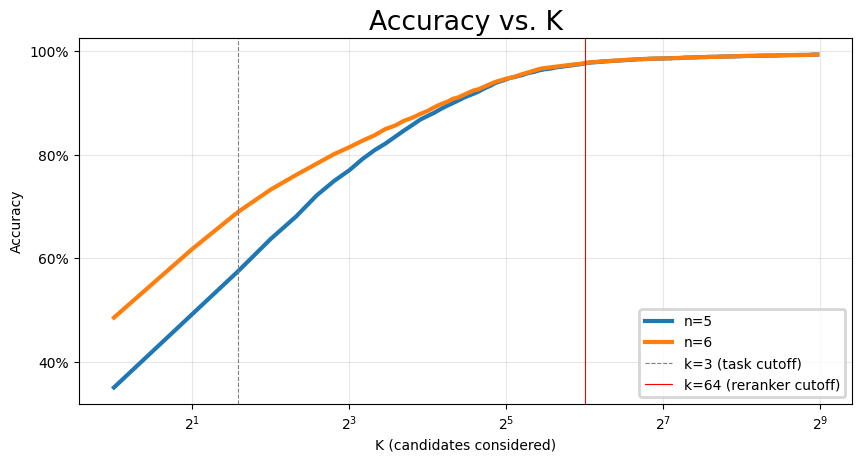

Saved to output/sweep_plot.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
# sns.set_theme()
sns.set_context("poster", font_scale=0.8)
sns.lineplot(data=df, x="k", y="accuracy", hue="model", ax=ax)

ax.axvline(x=3, color="grey", linestyle="--", linewidth=0.8, label="k=3 (task cutoff)")
ax.axvline(
    x=64, color="red", linestyle="-", linewidth=0.8, label="k=64 (reranker cutoff)"
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.set_xlabel("K (candidates considered)")
ax.set_xscale("log", base=2)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. K")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../output/sweep_plot.png", dpi=150)
plt.show()
print("Saved to output/sweep_plot.png")

In [5]:
# Print accuracy at key cutoffs for each model
key_ks = [1, 3, 5, 10, 20, 32, 64]
pivot = df[df["k"].isin(key_ks)].pivot(index="k", columns="model", values="accuracy")
pivot.index.name = "K"
pivot.columns.name = None
pivot.style.format("{:.2%}")

,n=5,n=6
K,,
1,35.04%,48.53%
3,57.53%,68.97%
5,68.06%,76.08%
10,80.87%,83.74%
20,89.99%,90.80%
32,94.57%,94.68%
64,97.61%,97.68%
